# import data and stuff

In [72]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import seaborn as sns
from sklearn.metrics import f1_score

In [73]:
# data loeading
from sklearn.datasets import make_circles, make_blobs

data = make_blobs(n_samples=1000, centers=5)
X1 = data[0][:,0]
X2 = data[0][:,1]
y = data[1]
df = pd.DataFrame({"X1":X1, "X2":X2,"y":y})
df

,X1,X2,y
0,8.426244,-4.342028,1
1,5.714649,-2.752326,1
2,7.994486,5.414104,0
3,8.906785,6.185466,0
4,-9.157751,3.315516,4
...,...,...,...
995,-5.918675,4.578373,2
996,-5.091127,7.878146,2
997,-5.658447,7.527388,2
998,7.335871,-4.430245,1


# start model shits

In [74]:
device = "cuda" if torch.cuda.is_available()==True else "cpu"
device

'cpu'

In [75]:
X = torch.from_numpy(data[0]).type(torch.float).to(device)
y = torch.from_numpy(data[1]).long().to(device)


# train test split

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test , y_train , y_test = train_test_split(X, y, random_state=47, test_size=0.2)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

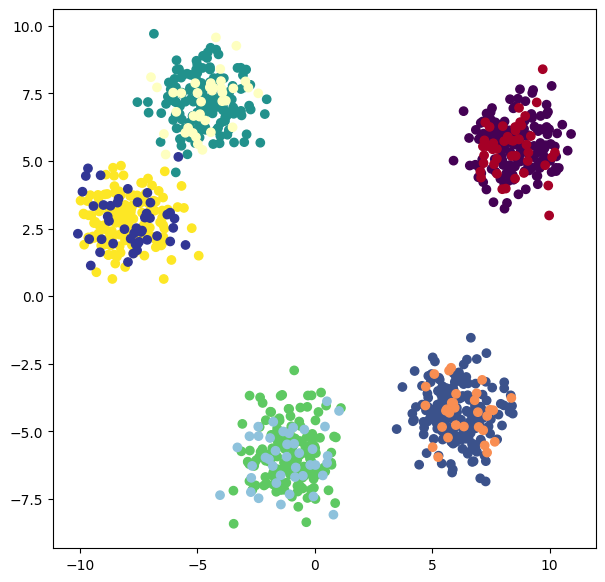

In [77]:
def plot(train_data=X_train,
         train_labels=y_train,
         test_data=X_test,
         test_labels=y_test,
         predictions=None):

    plt.figure(figsize=(7,7))
    plt.scatter(train_data[:,0].cpu().numpy(), train_data[:,1].cpu().numpy(), c=train_labels.cpu().numpy())
    plt.scatter(test_data[:,0].cpu().numpy(), test_data[:,1].cpu().numpy(), c=test_labels.cpu().numpy(), cmap=plt.cm.RdYlBu)

    plt.show()
    
plot()

In [ ]:
# main model:
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 5)
            )
        
    def forward(self, x):
        return self.network(x)

In [79]:
model = CircleModel().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.005)
model.state_dict()

OrderedDict([('network.0.weight',
              tensor([[-0.6321, -0.6365],
                      [-0.0457,  0.5313],
                      [ 0.0793,  0.4220],
                      [ 0.6728, -0.3561],
                      [-0.4993, -0.0926],
                      [ 0.2811,  0.5492],
                      [-0.3340, -0.3312],
                      [-0.5127, -0.0552]])),
             ('network.0.bias',
              tensor([ 0.3450, -0.6575, -0.5059, -0.1334,  0.0482,  0.1219, -0.4993, -0.2885])),
             ('network.2.weight',
              tensor([[-0.1599,  0.1670,  0.2911, -0.1920, -0.3118, -0.2026, -0.0104,  0.1820],
                      [-0.0095, -0.2933,  0.2132,  0.1742, -0.1020, -0.0668, -0.3336, -0.0657],
                      [-0.1205, -0.1308,  0.0292, -0.1061, -0.1416, -0.0297, -0.1125, -0.0725],
                      [-0.1143, -0.0854, -0.2370, -0.3531,  0.0527, -0.1569, -0.0563,  0.1839],
                      [-0.1898, -0.1634, -0.0221,  0.2626, -0.0441,  0.2175, -0.

In [80]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

In [81]:
y_logits = model(X_train)
y_pred = torch.argmax(y_logits)
loss = loss_fn(y_logits, y_train)
y_logits

tensor([[-0.6143, -0.4955,  1.1935,  0.4612, -0.0624],
        [-0.3617, -0.0039,  0.3634,  0.6079, -0.1382],
        [-0.5192, -0.3240,  0.4183,  0.2203,  0.3742],
        ...,
        [-1.0438, -0.7016,  1.3199,  0.7186,  0.5557],
        [-0.4047, -0.0513,  0.2504,  0.5889,  0.0170],
        [-0.4205, -0.0120,  0.3025,  0.7642, -0.0932]],
       grad_fn=<AddmmBackward0>)

In [ ]:
# main loop:

torch.manual_seed(47)

epochs = 900

train_loss_values = []
test_loss_values = []
train_r2_values = []
test_r2_values = []
epoch_count = []

for epoch in range(epochs):
    # train:
    model.train()
    y_logits = model(X_train)
    y_pred = torch.argmax(y_logits, dim=1)
    loss = loss_fn(y_logits, y_train)
    # backward:
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Calculate R² for training (regression metric)
    with torch.no_grad():
        train_f1 = f1_score(y_train.cpu().numpy(), y_pred.cpu().numpy(), average="weighted")
        
    # test evaluation:
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_pred = torch.argmax(test_logits, dim=1)
        test_loss = loss_fn(test_logits, y_test)
        test_f1 = f1_score(y_test.cpu().numpy(), test_pred.cpu().numpy(), average="weighted")
    
    # Store values
    epoch_count.append(epoch)
    train_loss_values.append(loss.item())
    test_loss_values.append(test_loss.item())
    train_r2_values.append(train_f1)
    test_r2_values.append(test_f1)
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f} | Train f1: {train_f1:.4f} | Test f1: {test_f1:.4f}")


Epoch: 0 | Train Loss: 1.6560 | Test Loss: 1.5813 | Train f1: 0.0492 | Test f1: 0.0589
Epoch: 10 | Train Loss: 1.0629 | Test Loss: 1.0136 | Train f1: 0.9799 | Test f1: 0.9851
Epoch: 20 | Train Loss: 0.5961 | Test Loss: 0.5662 | Train f1: 0.9950 | Test f1: 0.9900
Epoch: 30 | Train Loss: 0.2632 | Test Loss: 0.2517 | Train f1: 0.9987 | Test f1: 0.9950
Epoch: 40 | Train Loss: 0.1002 | Test Loss: 0.0988 | Train f1: 0.9987 | Test f1: 0.9950
Epoch: 50 | Train Loss: 0.0441 | Test Loss: 0.0481 | Train f1: 1.0000 | Test f1: 0.9950
Epoch: 60 | Train Loss: 0.0249 | Test Loss: 0.0313 | Train f1: 1.0000 | Test f1: 0.9950
Epoch: 70 | Train Loss: 0.0171 | Test Loss: 0.0246 | Train f1: 1.0000 | Test f1: 0.9950
Epoch: 80 | Train Loss: 0.0132 | Test Loss: 0.0214 | Train f1: 1.0000 | Test f1: 0.9950
Epoch: 90 | Train Loss: 0.0109 | Test Loss: 0.0195 | Train f1: 1.0000 | Test f1: 0.9950
Epoch: 100 | Train Loss: 0.0094 | Test Loss: 0.0183 | Train f1: 1.0000 | Test f1: 0.9950
Epoch: 110 | Train Loss: 0.0083 

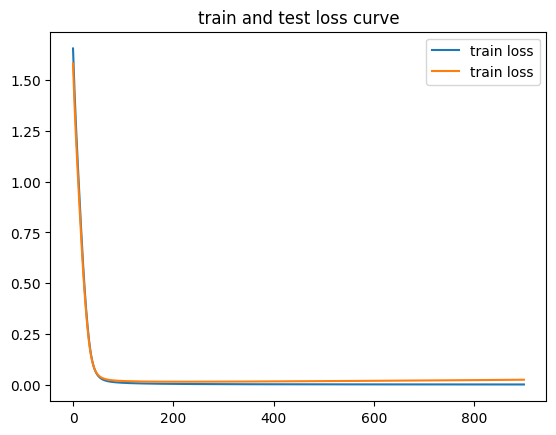

In [83]:
plt.title("train and test loss curve")
plt.plot(epoch_count, train_loss_values, label="train loss")
plt.plot(epoch_count, test_loss_values, label="train loss")
plt.legend()

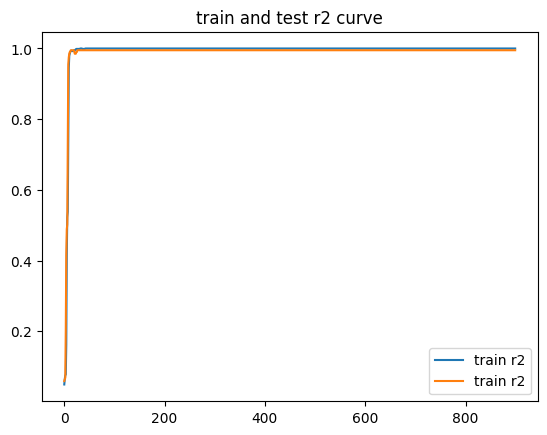

In [84]:
plt.title("train and test r2 curve")
plt.plot(epoch_count, train_r2_values, label="train r2")
plt.plot(epoch_count, test_r2_values, label="train r2")
plt.legend()

In [85]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [86]:
def plot_decision_boundary(model, X, y, device="cpu"):
    model.eval()

    x_min, x_max = X[:, 0].min().item() - 0.1, X[:, 0].max().item() + 0.1
    y_min, y_max = X[:, 1].min().item() - 0.1, X[:, 1].max().item() + 0.1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    X_to_pred = torch.from_numpy(
        np.c_[xx.ravel(), yy.ravel()]
    ).float().to(device)

    with torch.inference_mode():
        logits = model(X_to_pred)
        preds = torch.argmax(logits, dim=1)

    preds = preds.cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=(7,7))
    plt.contourf(xx, yy, preds, alpha=0.4, cmap=plt.cm.RdYlBu)

    plt.scatter(
        X[:,0].cpu(),
        X[:,1].cpu(),
        c=y.cpu(),
        cmap=plt.cm.RdYlBu,
        edgecolors="k"
    )

    plt.show()

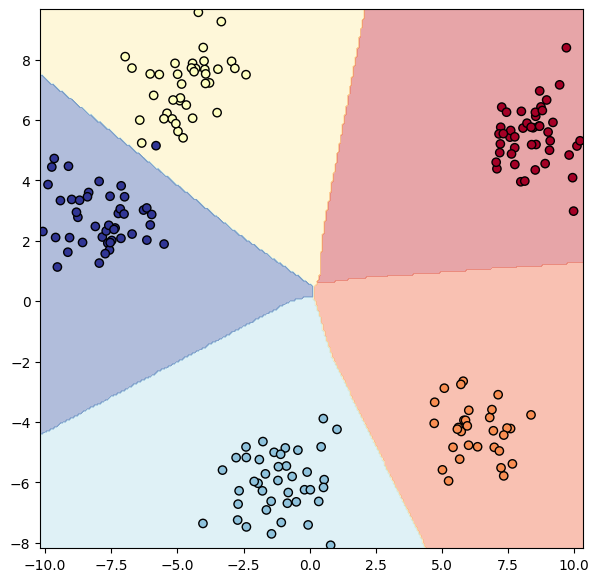

In [87]:
plot_decision_boundary(model, X_test, y_test, device)